In [8]:
import cv2
import matplotlib.pyplot as plt

from utils import *
from darknet import Darknet

import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.image import MIMEImage

In [9]:
# Set the location and name of the cfg file
cfg_file = './cfg/yolov3.cfg'

# Set the location and name of the pre-trained weights file
weight_file = './weights/yolov3.weights'

# Set the location and name of the COCO object classes file
namesfile = 'data/coco.names'

# Load the network architecture
m = Darknet(cfg_file)

# Load the pre-trained weights
m.load_weights(weight_file)

# Load the COCO object classes
class_names = load_class_names(namesfile)

In [10]:
# Print the neural network used in YOLOv3
m.print_network()

layer     filters    size              input                output
    0 conv     32  3 x 3 / 1   416 x 416 x   3   ->   416 x 416 x  32
    1 conv     64  3 x 3 / 2   416 x 416 x  32   ->   208 x 208 x  64
    2 conv     32  1 x 1 / 1   208 x 208 x  64   ->   208 x 208 x  32
    3 conv     64  3 x 3 / 1   208 x 208 x  32   ->   208 x 208 x  64
    4 shortcut 1
    5 conv    128  3 x 3 / 2   208 x 208 x  64   ->   104 x 104 x 128
    6 conv     64  1 x 1 / 1   104 x 104 x 128   ->   104 x 104 x  64
    7 conv    128  3 x 3 / 1   104 x 104 x  64   ->   104 x 104 x 128
    8 shortcut 5
    9 conv     64  1 x 1 / 1   104 x 104 x 128   ->   104 x 104 x  64
   10 conv    128  3 x 3 / 1   104 x 104 x  64   ->   104 x 104 x 128
   11 shortcut 8
   12 conv    256  3 x 3 / 2   104 x 104 x 128   ->    52 x  52 x 256
   13 conv    128  1 x 1 / 1    52 x  52 x 256   ->    52 x  52 x 128
   14 conv    256  3 x 3 / 1    52 x  52 x 128   ->    52 x  52 x 256
   15 shortcut 12
   16 conv    128  1 x 1

In [11]:
# Set the default figure size
plt.rcParams['figure.figsize'] = [24.0, 14.0]

# Load the image
img = cv2.imread('./images/test4.jpeg')

# Convert the image to RGB
original_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# We resize the image to the input width and height of the first layer of the network.    
resized_image = cv2.resize(original_image, (m.width, m.height))

# Display the images
# plt.subplot(121)
# plt.title('Original Image')
# plt.imshow(original_image)
# plt.subplot(122)
# plt.title('Resized Image')
# plt.imshow(resized_image)
# plt.show()

In [12]:
# Set the NMS threshold
nms_thresh = 0.6  

# Setting the Intersection Over Union Threshold

After removing all the predicted bounding boxes that have a low detection probability, the second step in NMS, is to select the bounding boxes with the highest detection probability and eliminate all the bounding boxes whose **Intersection Over Union (IOU)** value is higher than a given IOU threshold. In the code below, we set this IOU threshold to `0.4`. This means that all predicted bounding boxes that have an IOU value greater than 0.4 with respect to the best bounding boxes will be removed.

In the `utils` module you will find the `nms` function, that performs the second step of Non-Maximal Suppression, and the `boxes_iou` function that calculates the Intersection over Union of two given bounding boxes. You are encouraged to look at these functions to see how they work. 

In [13]:
# Set the IOU threshold
iou_thresh = 0.4



It took 0.384 seconds to detect the objects in the image.

Number of Objects Detected: 7 

Objects Found and Confidence Level:

1. laptop: 0.999991
2. person: 1.000000
3. laptop: 1.000000
4. person: 1.000000
5. cell phone: 0.999501
6. person: 1.000000
7. person: 1.000000
mapractice has been detected


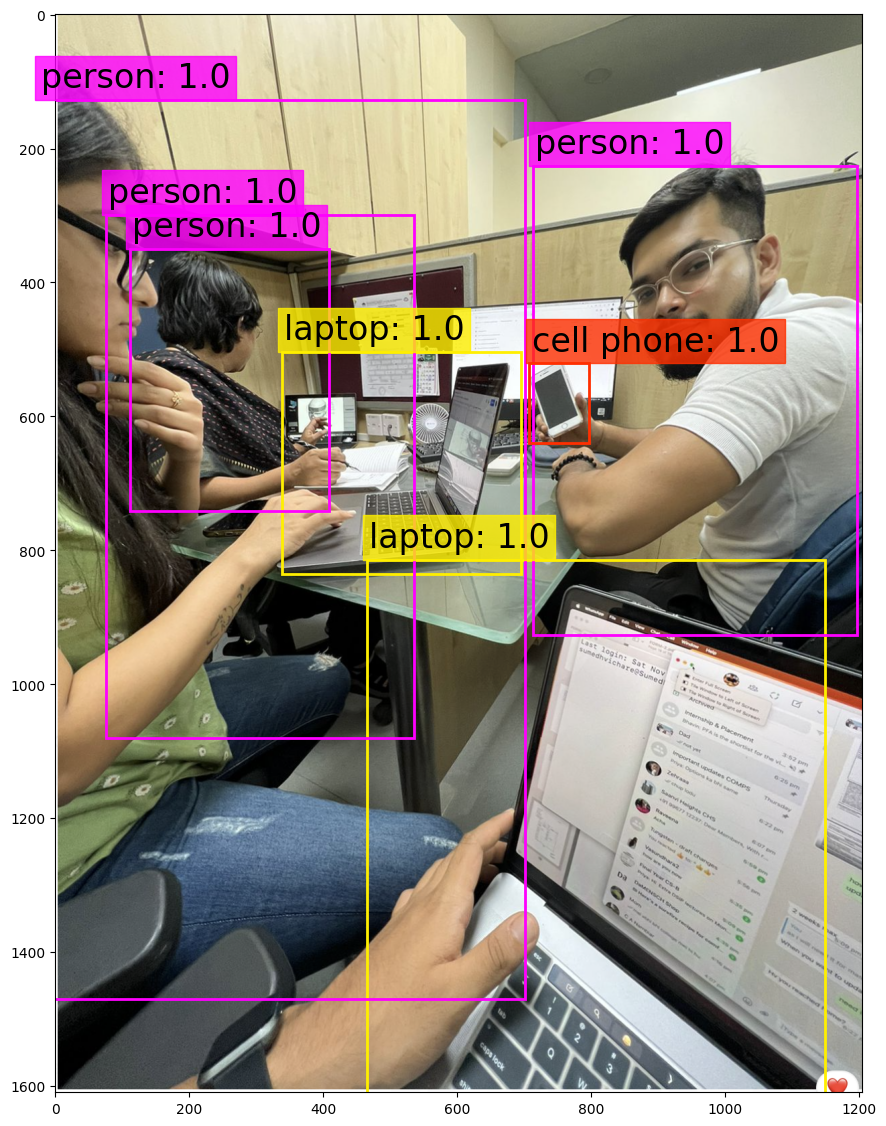

In [14]:
# Set the default figure size
plt.rcParams['figure.figsize'] = [24.0, 14.0]

# Load the image
img = cv2.imread('./images/test4.jpeg')

# Convert the image to RGB
original_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# We resize the image to the input width and height of the first layer of the network.    
resized_image = cv2.resize(original_image, (m.width, m.height))

# Set the IOU threshold. Default value is 0.4
iou_thresh = 0.4

# Set the NMS threshold. Default value is 0.6
nms_thresh = 0.6

# Detect objects in the image
boxes = detect_objects(m, resized_image, iou_thresh, nms_thresh)

# Print the objects found and the confidence level
print_objects(boxes, class_names)

person_counter=0
laptop_counter=0
phone_counter=0
for i in range(len(boxes)):
    box = boxes[i]
    if len(box) >= 7 and class_names:
        cls_conf = box[5]
        cls_id = box[6]
        if(class_names[cls_id]=="person"):
            person_counter+=1
        elif(class_names[cls_id]=="laptop"):
            laptop_counter+=1
        elif(class_names[cls_id]=="cell phone"):
            phone_counter+=1
if(phone_counter>=1 or laptop_counter>=2 or person_counter>=2):
    print('mapractice has been detected')
    # Set up the email message
    msg = MIMEMultipart()
    msg['From'] = 'zehraraj6@gmail.com'
    msg['To'] = 'zehratestt@gmail.com'
    msg['Subject'] = 'Malpractice Detected - SAP 60004200055'
    message = 'Please check!'
    msg.attach(MIMEText(message))

    # Attach the image
    with open('plottedimg.jpeg', 'rb') as fp:
        img_data = fp.read()
    img = MIMEImage(img_data, name='plottedimg')
    msg.attach(img)

    # Log in to the email server
    server = smtplib.SMTP('smtp.gmail.com', 587)
    server.starttls()
    server.login('zehraraj6@gmail.com', 'wmjuoskkdmpuerjp')

    # Send the email
    text = msg.as_string()
    server.sendmail('zehraraj6@gmail.com', 'zehratestt@gmail.com', text)
    server.quit()

else:
    print("no malpractice in this image")

#Plot the image with bounding boxes and corresponding object class labels

plot_boxes(original_image, boxes, class_names, plot_labels = True)